# Inverse Functions

**This notebook is self-contained; it recaps functions before inverting them.**

Recall that a **function** turns an input into exactly one output. Its **inverse** does the reverse: it takes an output and recovers the input that produced it, it **undoes** the function. If a function converts Celsius to Fahrenheit, its inverse converts Fahrenheit back to Celsius. This notebook explains when a function *has* an inverse (it must never send two different inputs to the same output), how to find a simple inverse, and why the graph of an inverse is a mirror image of the original.

## Learning objectives

- Describe an inverse as the "undo" of $f$: $f^{-1}(f(x)) = x$.
- Explain **one-to-one** and use the **horizontal line test**.
- Explain **onto**, and why invertibility needs both properties.
- Find the inverse of a simple function by algebra.
- See the inverse as a **reflection across the line $y = x$**.

## Background

The **inverse** of a function $f$, written $f^{-1}$, reverses it: whatever output $f$ produced, $f^{-1}$ sends it back to the original input, so $f^{-1}(f(x)) = x$.

A function has an inverse only if it is **one-to-one**, no two different inputs share the same output. (If two inputs gave the same output, the inverse would not know which one to return.) It must also be **onto**, every value in the target set has to be produced by something, or the inverse would be undefined there. You can check this visually with the **horizontal line test**: if any horizontal line crosses the graph more than once, the function is not one-to-one. Graphically, the inverse is the **mirror image** of the function across the diagonal line $y = x$. The exponential $2^x$ and the logarithm $\log_2 x$ are a classic inverse pair.

## This notebook covers

1. Undoing a function.
2. One-to-one and the horizontal line test.
3. Onto, and why both properties are needed.
4. Finding an inverse by algebra.
5. Inverse as reflection across $y = x$.
6. An application (unit conversion).

**Prerequisites:** `U1-3_Functions-1_DomainRangeAndFamilies`

**Dataset:** none.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

plt.style.use('dark_background')

import warnings
warnings.filterwarnings('ignore')

# --- plotting helper: draw x-y graphs like the usual coordinate plane ---
def center_axes(ax):
    ax.spines['left'].set_position('zero')     # y-axis through x = 0
    ax.spines['bottom'].set_position('zero')   # x-axis through y = 0
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

## 1. Undoing a function

Take $f(x) = 2x + 1$: it **doubles** the input and then **adds one**. To undo it, we reverse those steps in the opposite order, **subtract one**, then **halve**, which gives $f^{-1}(y) = (y-1)/2$. Applying $f$ and then $f^{-1}$ should return us to the number we started with.

In [2]:
def f(x):
    return 2 * x + 1          # double, then add 1

def f_inverse(y):
    return (y - 1) / 2         # subtract 1, then halve  (undoes f)

x = 5
forward = f(x)                 # 2*5 + 1 = 11
back = f_inverse(forward)      # (11 - 1)/2 = 5

print("f(5)            =", forward)
print("f_inverse(f(5)) =", back)

f(5)            = 11
f_inverse(f(5)) = 5.0


## 2. One-to-one and the horizontal line test

A function can be inverted only if it is **one-to-one**: every output comes from just one input. The quick visual check is the **horizontal line test**, slide a horizontal line up and down across the graph; if it ever touches the curve in two places, then two different inputs share that output and the function is *not* one-to-one. A straight line passes the test; a parabola fails it, because (for example) both $x = -2$ and $x = 2$ give $x^2 = 4$.

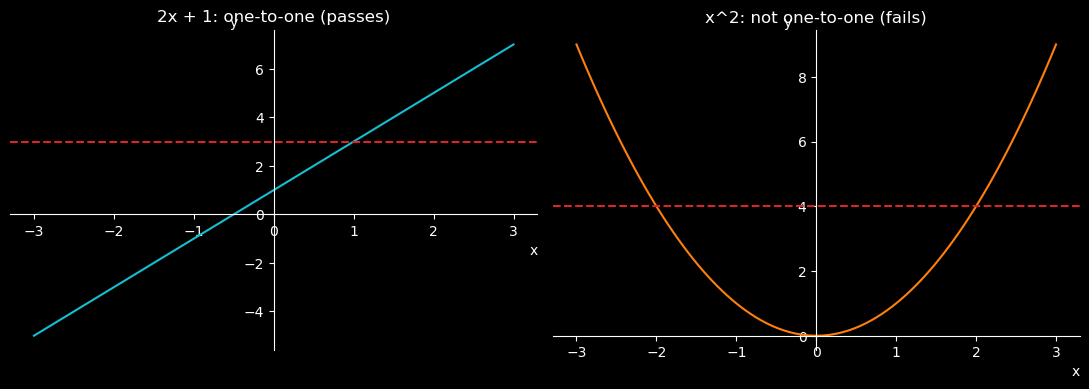

In [3]:
x = np.linspace(-3, 3, 100)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# one-to-one: a straight line
axes[0].plot(x, 2 * x + 1, color="tab:cyan")
axes[0].axhline(3, color="tab:red", ls="--")   # a horizontal line hits once
axes[0].set_title("2x + 1: one-to-one (passes)")

# not one-to-one: a parabola
axes[1].plot(x, x ** 2, color="tab:orange")
axes[1].axhline(4, color="tab:red", ls="--")   # hits twice (x = -2 and x = 2)
axes[1].set_title("x^2: not one-to-one (fails)")

for ax in axes:
    center_axes(ax)
    ax.set_xlabel("x", loc="right")
    ax.set_ylabel("y", loc="top", rotation=0)

plt.tight_layout()
plt.show()

The dashed horizontal line meets the straight line once (so $2x+1$ is invertible) but meets the parabola twice, at $x=-2$ and $x=2$ (so $x^2$ has no single inverse unless we restrict its domain).

## 3. Onto: does every output actually get used?

One-to-one asks whether two inputs can collide. **Onto** asks the opposite-facing question: *is every
value in the target set actually produced by something?*

A function is **onto** (the formal word is *surjective*) when its **range**, the outputs it really
produces, fills up the whole target set it was declared to map into. If some value in the target is
never hit, the function is not onto.

The exponential makes this concrete. Think of $f(x) = 2^{x}$ as a function from all real numbers to
all real numbers. It is one-to-one, no two inputs share an output, but it is **not onto**: no matter
how far left you go, $2^{x}$ stays strictly positive, so nothing ever produces $0$ or a negative
number. Half the target set is unreachable.


over x in [-8, 4], 2^x produces values from 0.003906 to 16.00
smallest output is still positive: True


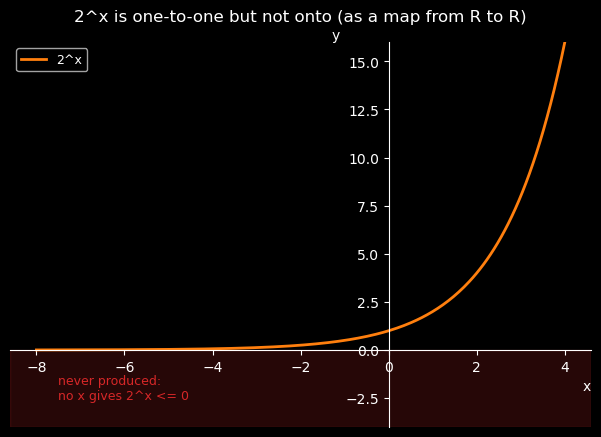

In [4]:
x = np.linspace(-8, 4, 300)
y = 2 ** x

print(f"over x in [{x.min():.0f}, {x.max():.0f}], 2^x produces values from {y.min():.6f} to {y.max():.2f}")
print(f"smallest output is still positive: {y.min() > 0}")

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.plot(x, y, color="tab:orange", lw=2, label="2^x")
# the part of the target set nothing ever reaches
ax.axhspan(-4, 0, color="tab:red", alpha=0.18)
ax.text(-7.5, -2, "never produced:\nno x gives 2^x <= 0", color="tab:red", fontsize=9, va="center")

center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_ylim(-4, 16)
ax.legend(loc="upper left", fontsize=9)
ax.set_title("2^x is one-to-one but not onto (as a map from R to R)", pad=15)
plt.show()


The shaded band is the giveaway: every value in it belongs to the target set, and none of them is
ever produced.

Here is the important subtlety, **being onto depends on what you declare the target set to be.**
Shrink the target from "all reals" to "the positive reals", and the very same formula *is* onto,
because now every value in the target genuinely gets used. Nothing about the function changed; only
the claim we made about it did.

That is exactly why $\log_2$ works. It is the inverse of $2^{x}$, and it accepts **only positive
inputs**, precisely the values $2^{x}$ actually produces. You will see this in section 5, where the
two curves mirror each other.

**Why both properties matter.** To invert a function you need both:

| Property | What it guarantees | What goes wrong without it |
|---|---|---|
| **one-to-one** | each output came from only one input | the inverse would not know which input to return |
| **onto** | every value in the target is produced | the inverse would be undefined on the values that are missed |

A function that is both is called a **bijection**, and a bijection is exactly a function that can be
inverted. In practice you can always *make* a function onto by shrinking the target set to its range,
so one-to-one is the property that does the real work, which is why it gets the famous test.


## 4. Finding an inverse by algebra

To find an inverse formula, write $y = f(x)$ and then solve for $x$ in terms of $y$:

$$y = 2x + 1 \ \Rightarrow\ y - 1 = 2x \ \Rightarrow\ x = \frac{y - 1}{2}.$$

So $f^{-1}(y) = (y-1)/2$, exactly the "subtract one, then halve" we guessed in Section 1. We can check it by running several inputs through $f$ and then through $f^{-1}$: each should come back to where it started.

In [5]:
# Check the inverse over several inputs: f_inverse(f(x)) should return x.
for x in [-2, 0, 3, 7]:
    print("x =", x, "-> f(x) =", f(x), "-> back =", f_inverse(f(x)))

x = -2 -> f(x) = -3 -> back = -2.0
x = 0 -> f(x) = 1 -> back = 0.0
x = 3 -> f(x) = 7 -> back = 3.0
x = 7 -> f(x) = 15 -> back = 7.0


## 5. Inverse as reflection across y = x

Plotted together with the line $y = x$, a function and its inverse are mirror images of each other. The exponential $2^x$ and the logarithm $\log_2 x$ show this clearly.

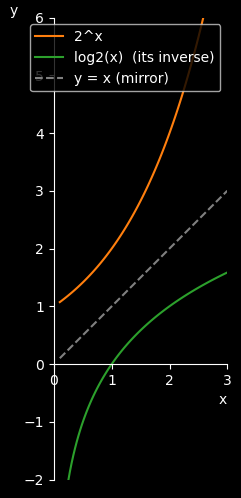

In [6]:
x_pos = np.linspace(0.1, 3, 100)

exp_x = 2 ** x_pos          # exponential
log_x = np.log2(x_pos)      # its inverse

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(x_pos, exp_x, label="2^x", color="tab:orange")
ax.plot(x_pos, log_x, label="log2(x)  (its inverse)", color="tab:green")
ax.plot(x_pos, x_pos, "--", color="gray", label="y = x (mirror)")
center_axes(ax)
ax.set_xlabel("x", loc="right")
ax.set_ylabel("y", loc="top", rotation=0)
ax.set_aspect("equal")
ax.set_xlim(0, 3)
ax.set_ylim(-2, 6)
ax.legend()
plt.show()

The green curve is the orange curve flipped across the dashed line $y = x$, that reflection *is* what "inverse function" means graphically.

## 6. Application: converting back

Everyday unit conversions are inverse-function pairs. Celsius to Fahrenheit is $F = \tfrac{9}{5}C + 32$; its inverse solves for $C$ and converts Fahrenheit back to Celsius. Converting one way and then back should return the original temperature.

In [7]:
def to_fahrenheit(celsius):
    return (9 / 5) * celsius + 32

def to_celsius(fahrenheit):
    return (fahrenheit - 32) * (5 / 9)   # the inverse

body_c = 37.0
f_value = to_fahrenheit(body_c)

print("37 C =", f_value, "F")
print("and back:", round(to_celsius(f_value), 1), "C")

37 C = 98.60000000000001 F
and back: 37.0 C


## 7. Summary

- An **inverse** $f^{-1}$ undoes $f$: $f^{-1}(f(x)) = x$.
- A function is invertible only if it is **one-to-one** (passes the horizontal line test) **and
  onto** (every target value gets produced). A function with both properties is a **bijection**.
- You find a simple inverse by writing $y = f(x)$ and solving for $x$.
- Graphically, $f^{-1}$ is the **reflection of $f$ across $y = x$**, and everyday unit conversions are inverse pairs.

Next: adding up long or endless lists of numbers, **series and convergence**
(`U1-4_Series-1_Convergence`).